# **Double Descent Phänomen** - Experimentelle Verifikation

Verifizieren Sie das Phänomen *Double Descent* experimentell (DL Framework; 3 unterschiedlich große Netzwerke; 3 unterschiedliche Mengen Trainingsdaten (synthetisch oder real))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Für Reproduzierbarkeit
np.random.seed(42)
torch.manual_seed(42)

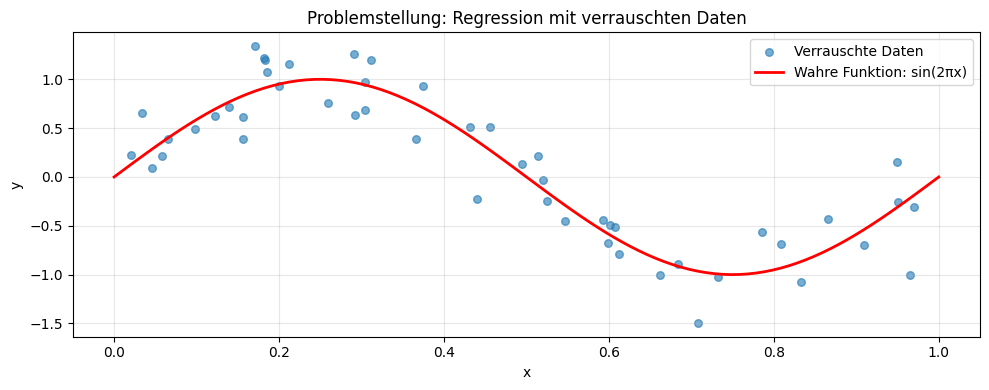

Aufgabe: Lerne sin(2πx) aus verrauschten Beobachtungen


In [3]:
# 1. SYNTHETISCHE DATEN GENERIEREN
# =================================

def generate_data(n_samples, noise_level=0.3):
    """
    Einfache nichtlineare Funktion: y = sin(2πx) + noise
    Gut geeignet um Interpolation vs. Generalisierung zu zeigen
    """
    X = np.random.uniform(0, 1, (n_samples, 1)).astype(np.float32)
    y_true = np.sin(2 * np.pi * X)
    noise = np.random.randn(n_samples, 1).astype(np.float32) * noise_level
    y = y_true + noise
    return X, y.flatten()

# Visualisierung der Zielfunktion
X_plot = np.linspace(0, 1, 100).reshape(-1, 1).astype(np.float32)
y_plot = np.sin(2 * np.pi * X_plot).flatten()

plt.figure(figsize=(10, 4))
X_demo, y_demo = generate_data(50, noise_level=0.3)
plt.scatter(X_demo, y_demo, alpha=0.6, label='Verrauschte Daten', s=30)
plt.plot(X_plot, y_plot, 'r-', linewidth=2, label='Wahre Funktion: sin(2πx)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Problemstellung: Regression mit verrauschten Daten')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Aufgabe: Lerne sin(2πx) aus verrauschten Beobachtungen")

In [4]:
# 2. NEURONALES NETZ DEFINIEREN
# ==============================

class FlexibleMLP(nn.Module):
    """
    Einfaches MLP mit variabler Breite (hidden_size)
    - 1 Input (x-Wert)
    - 1 Hidden Layer mit `hidden_size` Neuronen
    - 1 Output (y-Wert)
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        # Anzahl trainierbarer Parameter
        self.n_params = sum(p.numel() for p in self.parameters())
    
    def forward(self, x):
        return self.network(x)

# Beispiel: Parameter-Anzahl für verschiedene Größen
print("Modellgrößen (Anzahl Parameter):")
print("-" * 40)
for h in [5, 20, 100]:
    model = FlexibleMLP(h)
    print(f"Hidden Size {h:3d}: {model.n_params:5d} Parameter")

Modellgrößen (Anzahl Parameter):
----------------------------------------
Hidden Size   5:    46 Parameter
Hidden Size  20:   481 Parameter
Hidden Size 100: 10401 Parameter


In [5]:
# 3. TRAINING-FUNKTION
# =====================

def train_model(model, X_train, y_train, X_test, y_test, 
                epochs=2000, lr=0.01, verbose=False):
    """
    Trainiert ein Modell und gibt Train/Test MSE zurück
    """
    # Daten vorbereiten
    X_train_t = torch.FloatTensor(X_train).reshape(-1, 1)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_t = torch.FloatTensor(X_test).reshape(-1, 1)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)
    
    # Loss und Optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        # Logging alle 500 Epochen
        if epoch % 500 == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_t)
                test_pred = model(X_test_t)
                train_mse = criterion(train_pred, y_train_t).item()
                test_mse = criterion(test_pred, y_test_t).item()
                train_losses.append(train_mse)
                test_losses.append(test_mse)
                
                if verbose:
                    print(f"Epoch {epoch:4d}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")
    
    # Finale Metriken
    model.eval()
    with torch.no_grad():
        final_train_mse = criterion(model(X_train_t), y_train_t).item()
        final_test_mse = criterion(model(X_test_t), y_test_t).item()
    
    return final_train_mse, final_test_mse, model

# Test der Training-Funktion
print("Test-Training mit kleinem Netz...")
X, y = generate_data(100)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = FlexibleMLP(10)
train_mse, test_mse, _ = train_model(model, X_train, y_train, X_test, y_test, 
                                      epochs=1000, verbose=True)
print(f"\nFinales Ergebnis: Train={train_mse:.4f}, Test={test_mse:.4f}")

Test-Training mit kleinem Netz...
Epoch    0: Train MSE = 0.5085, Test MSE = 0.6294
Epoch  500: Train MSE = 0.1001, Test MSE = 0.0987
Epoch  999: Train MSE = 0.1002, Test MSE = 0.0918

Finales Ergebnis: Train=0.1002, Test=0.0918


In [12]:
# 4. HAUPT-EXPERIMENT: DOUBLE DESCENT
# ====================================

# Konfiguration
dataset_sizes = [100]  # Klein, Mittel, Groß
hidden_sizes = [2000]
n_repeats = 5  # Mehrere Durchläufe für stabilere Ergebnisse

# Ergebnisse speichern
results = {n: {'train': [], 'test': [], 'params': []} for n in dataset_sizes}

print("=" * 60)
print("DOUBLE DESCENT EXPERIMENT STARTET")
print("=" * 60)
print(f"Datensatzgrößen: {dataset_sizes}")
print(f"Hidden Layer Größen: {hidden_sizes}")
print(f"Wiederholungen pro Konfiguration: {n_repeats}")
print("-" * 60)

for n_samples in dataset_sizes:
    print(f"\n📊 Datensatzgröße: {n_samples} Samples")
    print("-" * 40)
    
    for hidden_size in hidden_sizes:
        train_mses = []
        test_mses = []
        
        for rep in range(n_repeats):
            # Neue Daten generieren
            X, y = generate_data(n_samples, noise_level=0.3)
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=rep
            )
            
            # Modell erstellen und trainieren
            model = FlexibleMLP(hidden_size)
            train_mse, test_mse, _ = train_model(
                model, X_train, y_train, X_test, y_test,
                epochs=3000, lr=0.01
            )
            
            train_mses.append(train_mse)
            test_mses.append(test_mse)
        
        # Durchschnitt speichern
        avg_train = np.mean(train_mses)
        avg_test = np.mean(test_mses)
        n_params = FlexibleMLP(hidden_size).n_params
        
        results[n_samples]['train'].append(avg_train)
        results[n_samples]['test'].append(avg_test)
        results[n_samples]['params'].append(n_params)
        
        # Interpolation-Threshold markieren
        interpolation_marker = " ← Interpolation!" if n_params > n_samples * 0.7 else ""
        print(f"  Hidden={hidden_size:3d} ({n_params:4d} params): "
              f"Train={avg_train:.4f}, Test={avg_test:.4f}{interpolation_marker}")

print("\n" + "=" * 60)
print("EXPERIMENT ABGESCHLOSSEN")
print("=" * 60)

DOUBLE DESCENT EXPERIMENT STARTET
Datensatzgrößen: [100]
Hidden Layer Größen: [2000]
Wiederholungen pro Konfiguration: 5
------------------------------------------------------------

📊 Datensatzgröße: 100 Samples
----------------------------------------
  Hidden=2000 (4008001 params): Train=0.0684, Test=0.1171 ← Interpolation!

EXPERIMENT ABGESCHLOSSEN


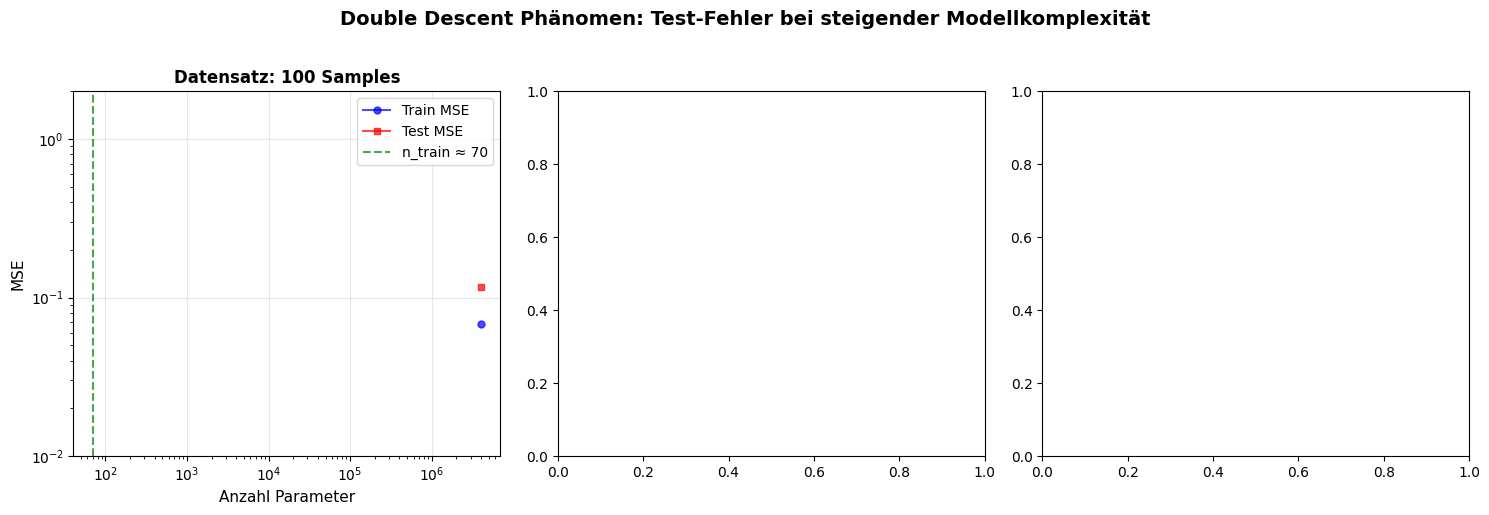

In [13]:
# 5. VISUALISIERUNG DER ERGEBNISSE
# ==================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'train': 'blue', 'test': 'red'}
markers = {'train': 'o', 'test': 's'}

for idx, n_samples in enumerate(dataset_sizes):
    ax = axes[idx]
    
    params = results[n_samples]['params']
    train_mse = results[n_samples]['train']
    test_mse = results[n_samples]['test']
    
    # Train und Test MSE plotten
    ax.plot(params, train_mse, 'b-o', label='Train MSE', markersize=5, alpha=0.7)
    ax.plot(params, test_mse, 'r-s', label='Test MSE', markersize=5, alpha=0.7)
    
    # Interpolation Threshold (Parameter ≈ Datenpunkte)
    n_train = int(n_samples * 0.7)
    ax.axvline(x=n_train, color='green', linestyle='--', alpha=0.7,
               label=f'n_train ≈ {n_train}')
    
    # Beschriftung
    ax.set_xlabel('Anzahl Parameter', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.set_title(f'Datensatz: {n_samples} Samples', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.01, 2])

plt.suptitle('Double Descent Phänomen: Test-Fehler bei steigender Modellkomplexität', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

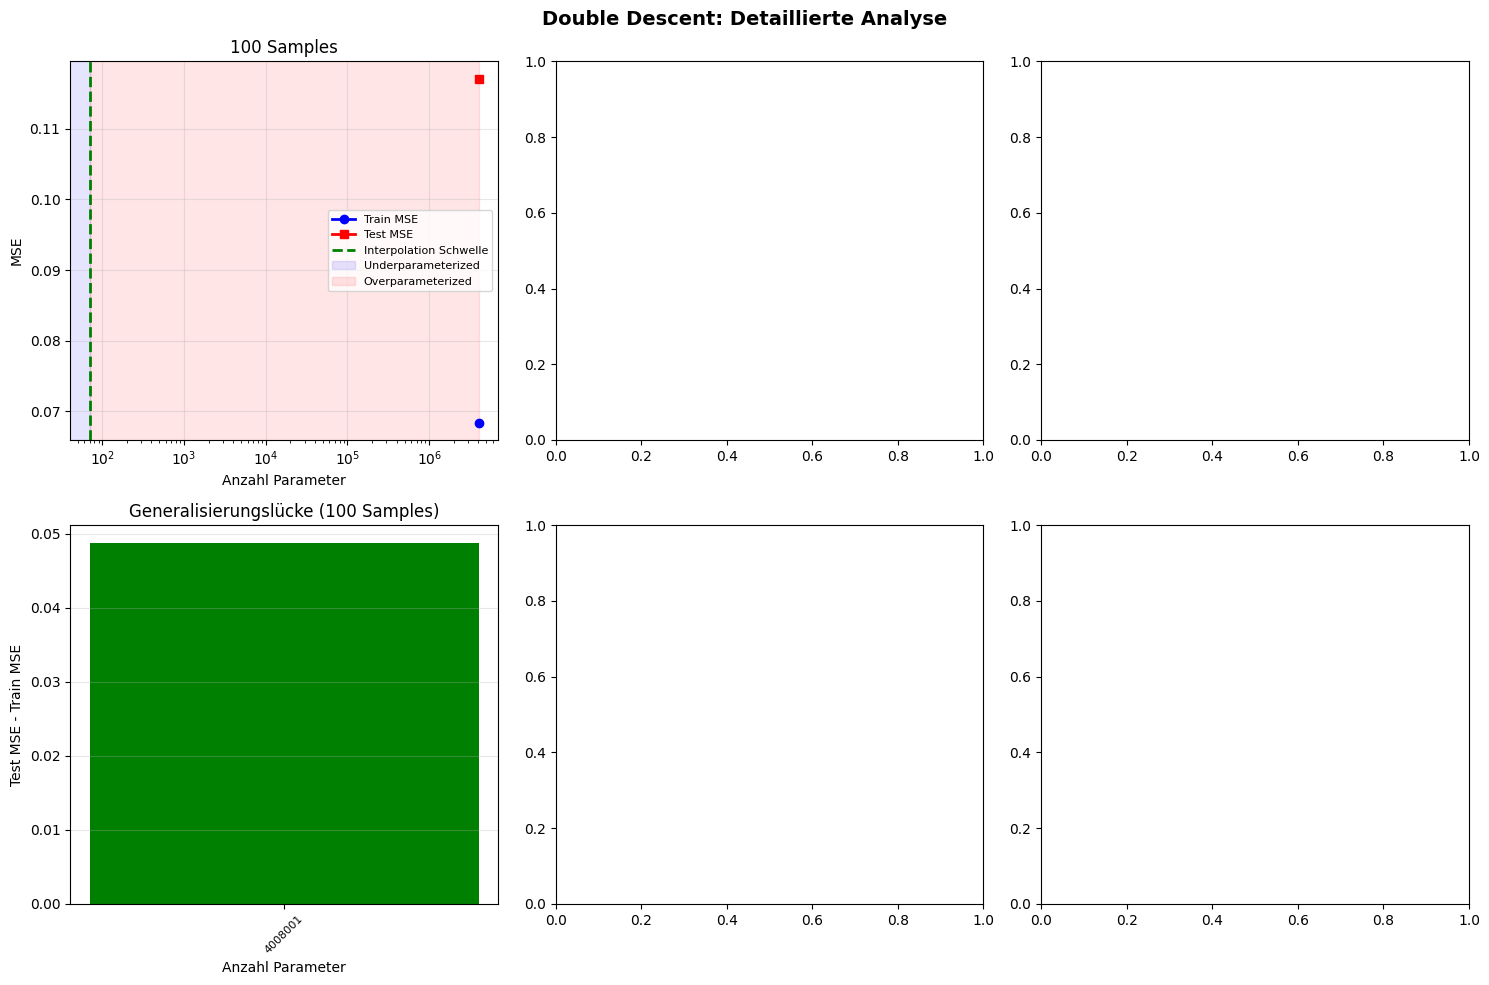

In [14]:
# 6. DETAILLIERTE ANALYSE
# ========================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, n_samples in enumerate(dataset_sizes):
    # Obere Reihe: MSE Kurven (linear scale für bessere Sichtbarkeit)
    ax1 = axes[0, idx]
    params = results[n_samples]['params']
    train_mse = results[n_samples]['train']
    test_mse = results[n_samples]['test']
    
    ax1.plot(params, train_mse, 'b-o', label='Train MSE', linewidth=2, markersize=6)
    ax1.plot(params, test_mse, 'r-s', label='Test MSE', linewidth=2, markersize=6)
    
    n_train = int(n_samples * 0.7)
    ax1.axvline(x=n_train, color='green', linestyle='--', linewidth=2,
                label=f'Interpolation Schwelle')
    
    # Bereiche markieren
    ax1.axvspan(0, n_train, alpha=0.1, color='blue', label='Underparameterized')
    ax1.axvspan(n_train, max(params), alpha=0.1, color='red', label='Overparameterized')
    
    ax1.set_xlabel('Anzahl Parameter')
    ax1.set_ylabel('MSE')
    ax1.set_title(f'{n_samples} Samples')
    ax1.legend(fontsize=8)
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    
    # Untere Reihe: Generalisierungslücke
    ax2 = axes[1, idx]
    gap = np.array(test_mse) - np.array(train_mse)
    ax2.bar(range(len(params)), gap, color=['green' if g < 0.1 else 'orange' if g < 0.3 else 'red' for g in gap])
    ax2.set_xticks(range(len(params)))
    ax2.set_xticklabels([str(p) for p in params], rotation=45, fontsize=8)
    ax2.set_xlabel('Anzahl Parameter')
    ax2.set_ylabel('Test MSE - Train MSE')
    ax2.set_title(f'Generalisierungslücke ({n_samples} Samples)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Double Descent: Detaillierte Analyse', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

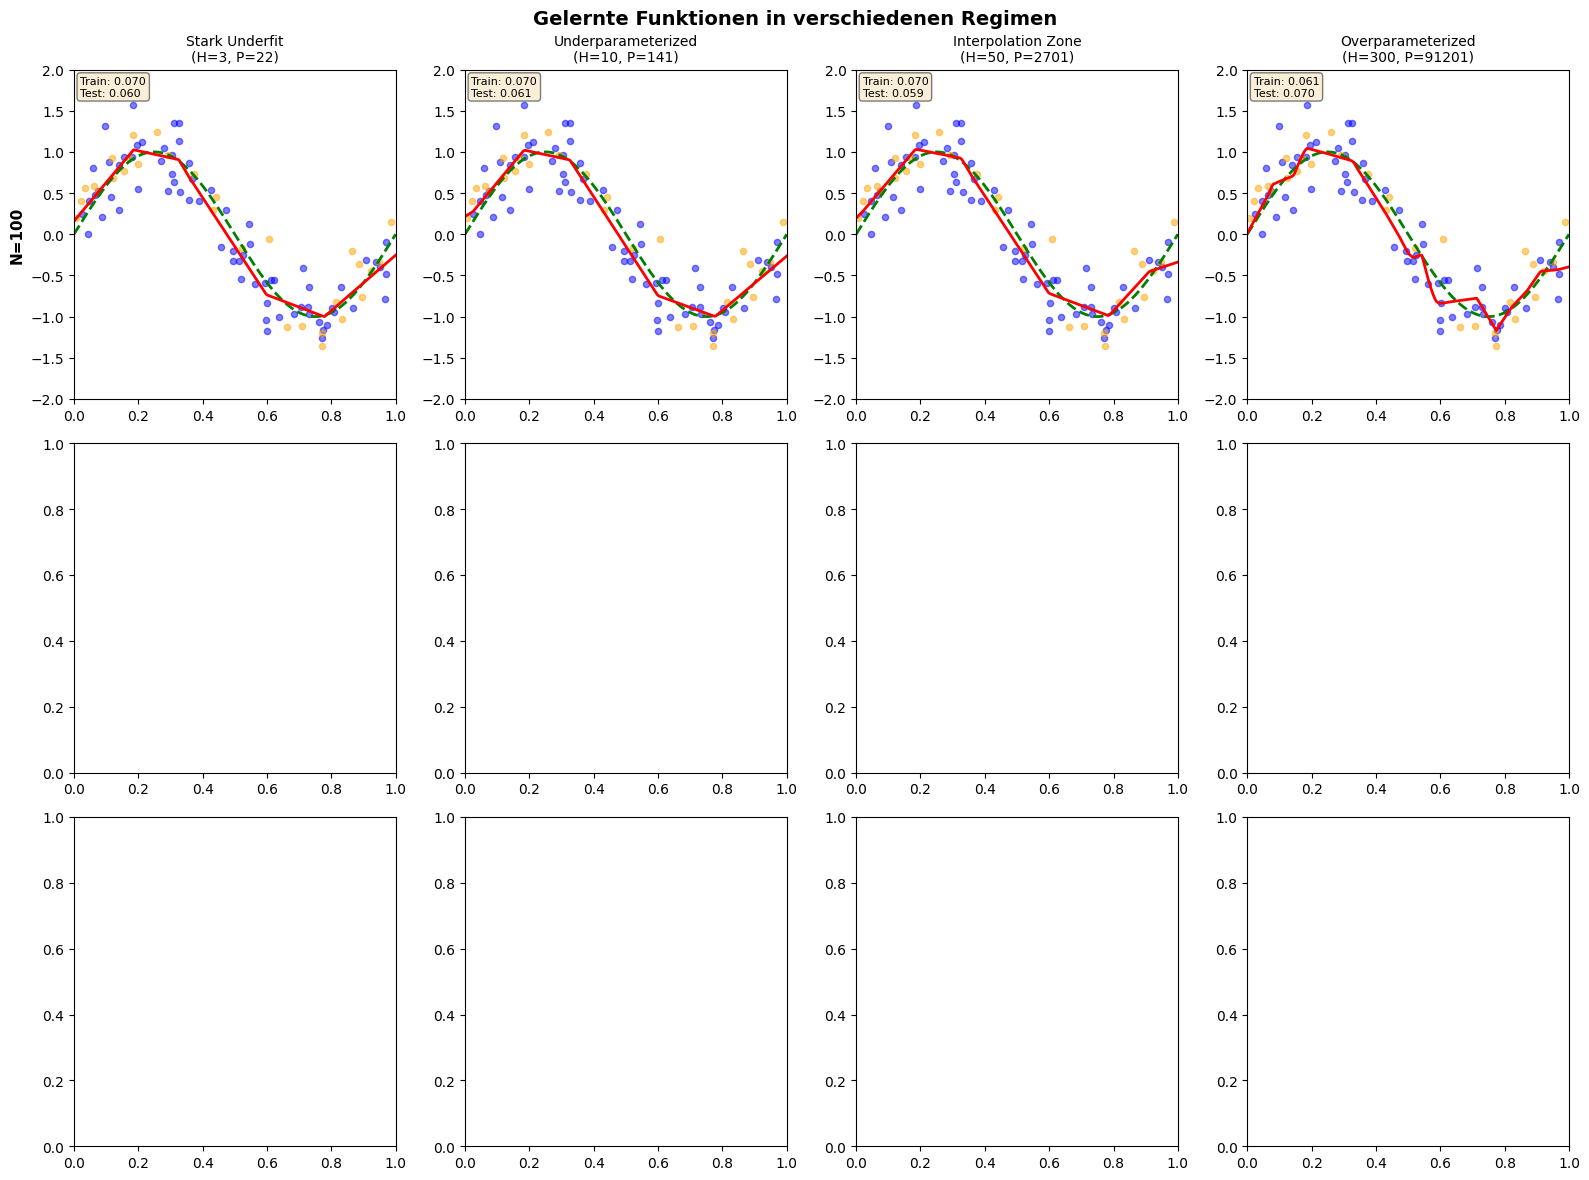

In [15]:
# 7. VISUALISIERUNG DER GELERNTEN FUNKTIONEN
# ============================================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Repräsentative Hidden Sizes für verschiedene Regime
hidden_sizes_demo = [3, 10, 50, 300]
regime_names = ['Stark Underfit', 'Underparameterized', 'Interpolation Zone', 'Overparameterized']

X_plot = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
y_true = np.sin(2 * np.pi * X_plot).flatten()

for row_idx, n_samples in enumerate(dataset_sizes):
    # Daten generieren
    np.random.seed(42)
    X, y = generate_data(n_samples , noise_level=0.3)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    for col_idx, hidden_size in enumerate(hidden_sizes_demo):
        ax = axes[row_idx, col_idx]
        
        # Modell trainieren
        torch.manual_seed(42)
        model = FlexibleMLP(hidden_size)
        train_mse, test_mse, trained_model = train_model(
            model, X_train, y_train, X_test, y_test,
            epochs=3000, lr=0.01
        )
        
        # Vorhersage
        trained_model.eval()
        with torch.no_grad():
            X_plot_t = torch.FloatTensor(X_plot)
            y_pred = trained_model(X_plot_t).numpy().flatten()
        
        # Plotten
        ax.scatter(X_train, y_train, c='blue', alpha=0.5, s=20, label='Train')
        ax.scatter(X_test, y_test, c='orange', alpha=0.5, s=20, label='Test')
        ax.plot(X_plot, y_true, 'g--', linewidth=2, label='Wahre Funktion')
        ax.plot(X_plot, y_pred, 'r-', linewidth=2, label='Modell')
        
        ax.set_xlim([0, 1])
        ax.set_ylim([-2, 2])
        
        if row_idx == 0:
            ax.set_title(f'{regime_names[col_idx]}\n(H={hidden_size}, P={model.n_params})', fontsize=10)
        else:
            ax.set_title(f'H={hidden_size}, P={model.n_params}', fontsize=10)
        
        if col_idx == 0:
            ax.set_ylabel(f'N={n_samples}', fontsize=11, fontweight='bold')
        
        # Metriken anzeigen
        ax.text(0.02, 0.98, f'Train: {train_mse:.3f}\nTest: {test_mse:.3f}',
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        if row_idx == 2 and col_idx == 3:
            ax.legend(loc='lower right', fontsize=7)

plt.suptitle('Gelernte Funktionen in verschiedenen Regimen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

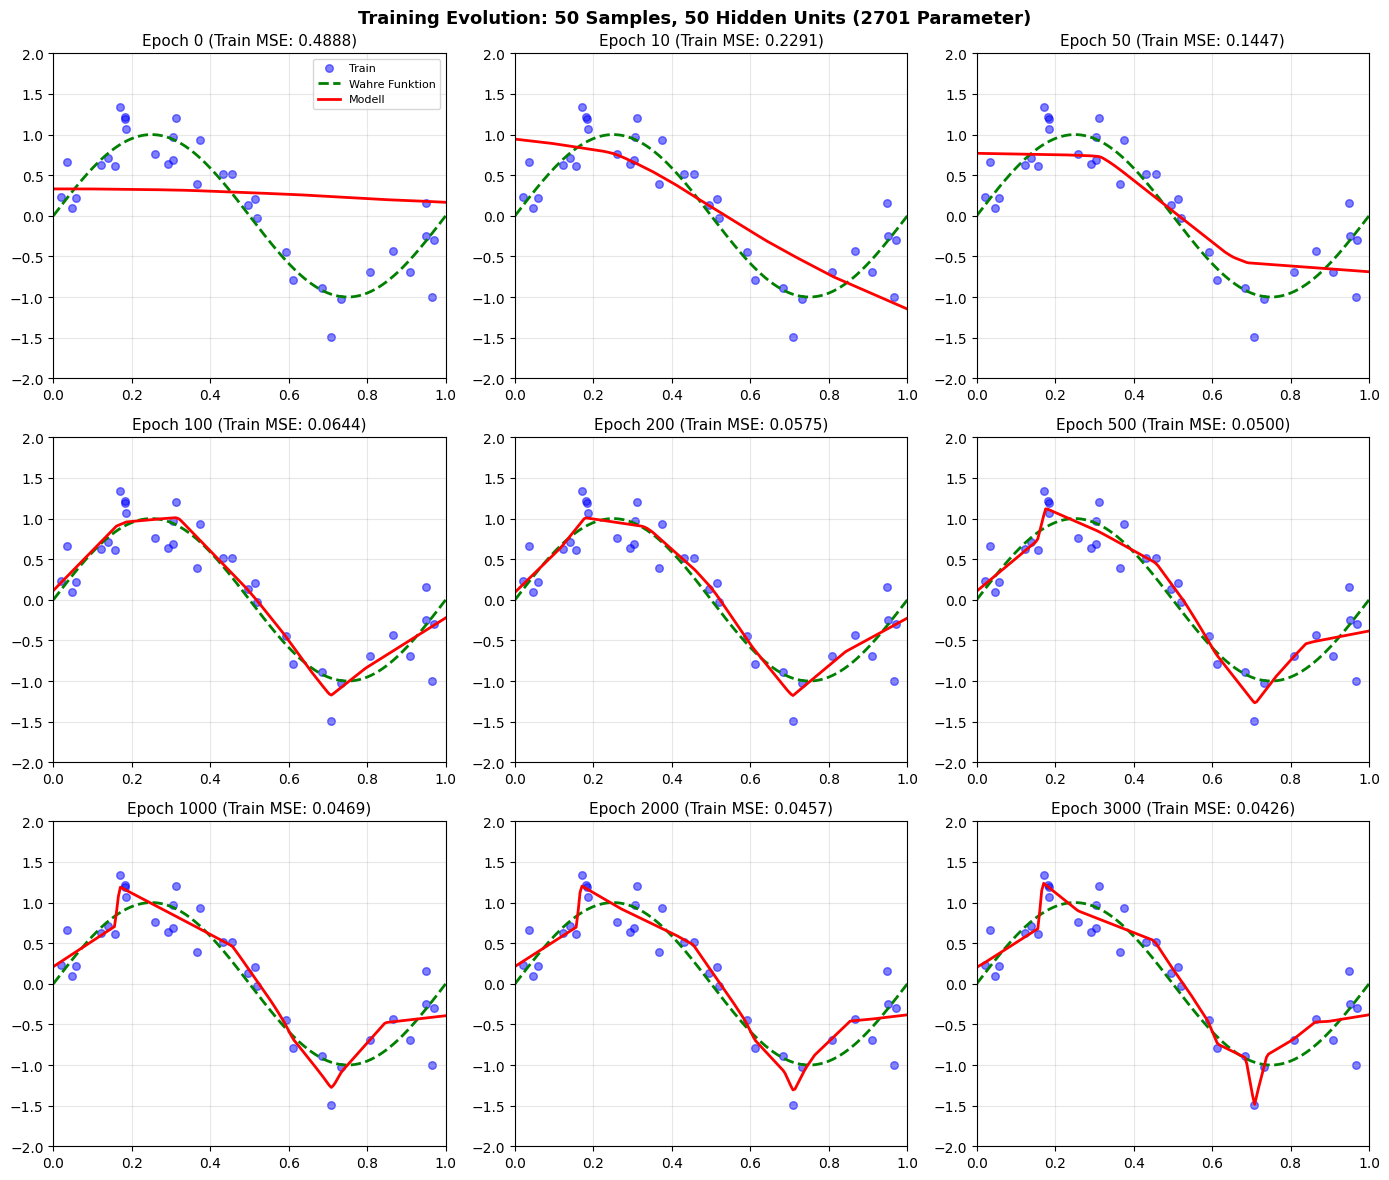


✅ Das Modell lernt zunächst grobe Strukturen, dann Details.
   In der Interpolation-Zone passt es sich auch dem Rauschen an!


In [11]:
# 9. BONUS: ANIMATION DES LERNPROZESSES
# ======================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Für ein ausgewähltes Setup: Zeige wie sich die Funktion während des Trainings entwickelt
n_samples = 50
hidden_size = 50  # In der Interpolation-Zone

np.random.seed(42)
torch.manual_seed(42)

X, y = generate_data(n_samples, noise_level=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modell und Training-Setup
model = FlexibleMLP(hidden_size)
X_train_t = torch.FloatTensor(X_train).reshape(-1, 1)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Snapshots während des Trainings
X_plot = np.linspace(0, 1, 200).reshape(-1, 1).astype(np.float32)
X_plot_t = torch.FloatTensor(X_plot)
y_true = np.sin(2 * np.pi * X_plot).flatten()

snapshots = []
epochs_to_record = [0, 10, 50, 100, 200, 500, 1000, 2000, 3000]

for epoch in range(3001):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    
    if epoch in epochs_to_record:
        model.eval()
        with torch.no_grad():
            y_pred = model(X_plot_t).numpy().flatten()
            train_mse = criterion(model(X_train_t), y_train_t).item()
        snapshots.append((epoch, y_pred.copy(), train_mse))

# Statische Visualisierung der Snapshots
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for idx, (epoch, y_pred, train_mse) in enumerate(snapshots):
    ax = axes[idx // 3, idx % 3]
    
    ax.scatter(X_train, y_train, c='blue', alpha=0.5, s=30, label='Train')
    ax.plot(X_plot, y_true, 'g--', linewidth=2, label='Wahre Funktion')
    ax.plot(X_plot, y_pred, 'r-', linewidth=2, label='Modell')
    
    ax.set_xlim([0, 1])
    ax.set_ylim([-2, 2])
    ax.set_title(f'Epoch {epoch} (Train MSE: {train_mse:.4f})', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.suptitle(f'Training Evolution: {n_samples} Samples, {hidden_size} Hidden Units ({model.n_params} Parameter)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Das Modell lernt zunächst grobe Strukturen, dann Details.")
print("   In der Interpolation-Zone passt es sich auch dem Rauschen an!")